# 01 — Data Cleaning Base

This notebook loads, cleans, merges, validates, and exports the base data for the full Vanguard project.

In [608]:

import pandas as pd
import numpy as np
import os
from  pathlib import Path
import importlib as plt
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RAW_DATA_PATH = "raw_data"
PROCESSED_DATA_PATH = "processed_data"

os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)


## Load raw data

In [609]:

demo = pd.read_csv(f"{RAW_DATA_PATH}/df_final_demo.csv")
experiment = pd.read_csv(f"{RAW_DATA_PATH}/df_final_experiment_clients.csv")
web_pt1 = pd.read_csv(f"{RAW_DATA_PATH}/df_final_web_data_pt_1.csv")
web_pt2 = pd.read_csv(f"{RAW_DATA_PATH}/df_final_web_data_pt_2.csv")

print("Demo:", demo.shape)
print("Experiment:", experiment.shape)
print("Web part 1:", web_pt1.shape)
print("Web part 2:", web_pt2.shape)


Demo: (70609, 9)
Experiment: (70609, 2)
Web part 1: (343141, 5)
Web part 2: (412264, 5)


## Explore Datasets
- Client Profiles (df_final_demo): Demographics like age, gender, and account details of our clients.
- Digital Footprints (df_final_web_data): A detailed trace of client interactions online, divided into two parts: pt_1 and pt_2.
- Experiment Roster (df_final_experiment_clients): A list revealing which clients were part of the grand experiment.
- Project Phases & Tasks

| Column               | Description                                             |
| -------------------- | ------------------------------------------------------- |
| **client_id**        | Unique identifier for each client                       |
| **variation**        | Indicates whether the client was part of the experiment |
| **visitor_id**       | Unique ID for each client–device combination            |
| **visit_id**         | Unique identifier for each web visit/session            |
| **process_step**     | Represents each step in the digital process             |
| **date_time**        | Timestamp of each web activity                          |
| **clnt_tenure_yr**   | Client tenure with Vanguard (in years)                  |
| **clnt_tenure_mnth** | Client tenure with Vanguard (in months)                 |
| **clnt_age**         | Age of the client                                       |
| **gendr**            | Gender of the client                                    |
| **num_accts**        | Number of accounts held by the client                   |
| **bal**              | Total balance across all client accounts                |
| **calls_6_mnth**     | Number of calls made by the client in the past 6 months |
| **logons_6_mnth**    | Number of platform logins in the past 6 months          |

## Standardize column names

In [610]:

def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df

demo = clean_column_names(demo)
experiment = clean_column_names(experiment)
web_pt1 = clean_column_names(web_pt1)
web_pt2 = clean_column_names(web_pt2)


## Combine web data

In [611]:

web = pd.concat([web_pt1, web_pt2], ignore_index=True)

print("Combined web shape:", web.shape)
web.head()


Combined web shape: (755405, 5)


,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


## Check missing values

In [612]:

display(demo.isna().sum())
display(experiment.isna().sum())
display(web.isna().sum())


client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

client_id        0
variation    20109
dtype: int64

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

## Remove duplicates

In [613]:

print("Duplicates before:")
print("Demo:", demo.duplicated().sum())
print("Experiment:", experiment.duplicated().sum())
print("Web:", web.duplicated().sum())

demo = demo.drop_duplicates()
experiment = experiment.drop_duplicates()
web = web.drop_duplicates()

print("Duplicates after:")
print("Demo:", demo.duplicated().sum())
print("Experiment:", experiment.duplicated().sum())
print("Web:", web.duplicated().sum())


Duplicates before:
Demo: 0
Experiment: 0
Web: 10764
Duplicates after:
Demo: 0
Experiment: 0
Web: 0


## Check a percentage of clients reaching each step

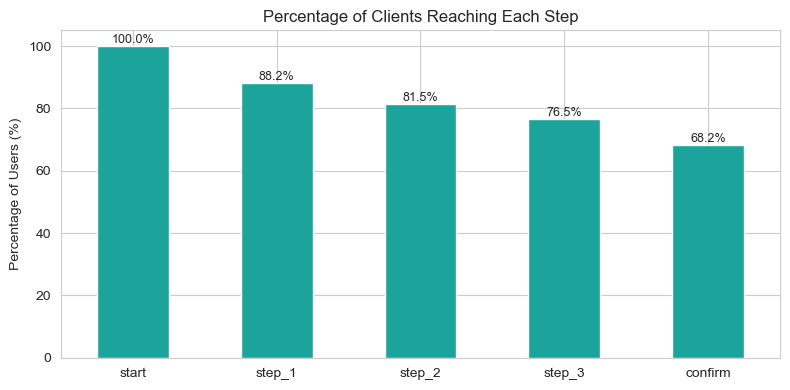

In [614]:
step_order = ["start", "step_1", "step_2", "step_3", "confirm"]

# Count unique clients per step
clients_per_step = (
    web.groupby("process_step")["client_id"]
    .nunique()
    .reindex(step_order)
)

# Convert counts to percentage
clients_pct = (clients_per_step / clients_per_step.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(8, 4))

clients_pct.plot(
    kind="bar",
    ax=ax,
    color="#1ca39c",
    edgecolor="white"
)

ax.set_title("Percentage of Clients Reaching Each Step")
ax.set_ylabel("Percentage of Users (%)")
ax.set_xlabel("")
ax.set_xticklabels(step_order, rotation=0)
ax.set_ylim(0, 105)

# Add percentage labels on top
for i, v in enumerate(clients_pct.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()
plt.show()

## Clean experiment data

In [615]:

experiment["variation"] = experiment["variation"].str.lower().str.strip()

display(experiment["variation"].value_counts(dropna=False))

experiment = experiment.dropna(subset=["variation"])
experiment = experiment[experiment["variation"].isin(["control", "test"])]

display(experiment["variation"].value_counts())


variation
test       26968
control    23532
NaN        20109
Name: count, dtype: int64

variation
test       26968
control    23532
Name: count, dtype: int64

## Clean process steps

In [616]:

web["process_step"] = web["process_step"].str.lower().str.strip()

step_mapping = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

web["step_num"] = web["process_step"].map(step_mapping)

display(web["process_step"].value_counts(dropna=False))
display(web[web["step_num"].isna()]["process_step"].value_counts())


process_step
start      234999
step_1     162797
step_2     132750
step_3     111589
confirm    102506
Name: count, dtype: int64

Series([], Name: count, dtype: int64)

## Convert date and time

In [617]:

web["date_time"] = pd.to_datetime(web["date_time"], errors="coerce")

web["date"] = web["date_time"].dt.date
web["time"] = web["date_time"].dt.time
web["hour"] = web["date_time"].dt.hour
web["weekday"] = web["date_time"].dt.day_name()


## Clean demographic data

In [618]:

demo = demo.drop_duplicates(subset=["client_id"])

print("Demo shape:", demo.shape)
display(demo.isna().sum())


Demo shape: (70609, 9)


client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [619]:
# Drop the rows with missing values since they were only 14/15 rows and they were not affecting the overall distribution of the data.
demo.dropna(inplace=True) 

In [620]:
# Keep only 3 genders U (Unknown), M (Male), F (Female)
demo["gendr"].replace({"X": "U"}, inplace=True)

/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_22438/1226791371.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  demo["gendr"].replace({"X": "U"}, inplace=True)


In [621]:
# Check a percentage of clients per gender
gendr_percentage=(demo["gendr"].value_counts()/len(demo["gendr"])*100).round(2)
gendr_percentage

gendr
U    34.17
M    33.61
F    32.22
Name: count, dtype: float64

## Create the age groups

In [622]:
bins = [18, 35, 45, 55, 65, 200]
labels = ['18-34', '35-44', '45-54', '55-64', '65+']

demo["age_group"] = pd.cut(demo["clnt_age"], bins=bins, labels=labels, include_lowest=True)

In [623]:
grouped = (
    demo.groupby(["gendr", "age_group"])
    .size()
    .reset_index(name="count")
)

grouped.head(3)

/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_22438/860182869.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demo.groupby(["gendr", "age_group"])


,gendr,age_group,count
0,F,18-34,4747
1,F,35-44,3953
2,F,45-54,5154


## 🧩 Data Hierarchy

```
client (client_id)
└── visitor (visitor_id) — one per device the client uses
    └── visit (visit_id) — one per session/web visit
        └── process_step — one action within that session
```

---

## 📌 Key Notes

- A single **client** can:
  - Use **multiple devices** → multiple `visitor_id`
  - Have **multiple visits per device** → multiple `visit_id`
  - Perform **multiple steps per visit** → multiple rows per `visit_id`

---

## 🎯 Why This Matters

Understanding this hierarchy determines how you measure and analyze behavior:

- **Completion rate**
  - Should it be measured per **client**, **visitor**, or **visit**?

- **Time per step**
  - Must be calculated **within the same visit/session**

- **Error rate**
  - Example: users going **backwards within a visit**

- **Avoid incorrect counting**
  - Counting rows ≠ counting visits or clients

```
client (client_id)
└── visitor (visitor_id) — one per device the client uses
    └── visit (visit_id) — one per session/web visit
        └── process_step — one action within that session
```

## 🔗 How the Datasets Connect

All three datasets link through `client_id`:

```
demo (client profile)
        └── client_id → Full picture per client
experiment (Test/Ctrl)
        └── client_id → Full picture per client
web (activity logs)
        └── client_id → Web behavior per client
```

---

## 📌 Key Idea

- `client_id` is the **common key** across all datasets  
- It allows you to **merge data** and build a **complete view of each client**

---

## ⚠️ Before Merging — Important Check

Always verify whether all clients appear in all datasets:

- Are there clients in **experiment** but not in **web**?
- Are there clients in **web** but not in **experiment**?
- Do all clients exist in **demo**?

---

## Merge datasets

In [624]:

client_data = demo.merge(
    experiment,
    on="client_id",
    how="inner"
)

clean_data = web.merge(
    client_data,
    on="client_id",
    how="inner"
)

print("Client data shape:", client_data.shape)
print("Clean data shape:", clean_data.shape)

clean_data.head()


Client data shape: (50487, 11)
Clean data shape: (317123, 20)


,client_id,visitor_id,visit_id,process_step,date_time,step_num,date,time,hour,weekday,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group,variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,3,2017-04-17,15:27:07,15,Monday,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,65+,test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,2,2017-04-17,15:26:51,15,Monday,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,65+,test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,3,2017-04-17,15:19:22,15,Monday,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,65+,test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,2,2017-04-17,15:19:13,15,Monday,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,65+,test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,3,2017-04-17,15:18:04,15,Monday,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,65+,test


## Check the average time per Completed session (from step 1 to step 5)

In [625]:
# Users who actually complete the full flow (step 1 → step 5).
df_sorted = clean_data.sort_values(["visit_id", "date_time"])

# Keep only sessions that reached step 5
completed_sessions = (
    df_sorted.groupby("visit_id")["step_num"]
    .max()
    .reset_index()
)

completed_sessions = completed_sessions[completed_sessions["step_num"] == 4]

# Filter original data to only completed sessions
df_completed = df_sorted[df_sorted["visit_id"].isin(completed_sessions["visit_id"])]

# Get start and end time per session
session_duration = (
    df_completed.groupby(["visit_id", "variation"])
    .agg(
        start_time=("date_time", "min"),
        end_time=("date_time", "max")
    )
    .reset_index()
)

# Compute duration
session_duration["duration_sec"] = (
    session_duration["end_time"] - session_duration["start_time"]
).dt.total_seconds()

# Convert to minutes
session_duration["duration_min"] = session_duration["duration_sec"] / 60

# Average per variation
avg_completion_time = (
    session_duration.groupby("variation")["duration_min"]
    .mean()
    .reset_index().round(2)
)

print(avg_completion_time)

  variation  duration_min
0   control          6.57
1      test          6.04


In [626]:
completion_rate = (
    session_data
    .groupby("variation")
    .agg(
        total_sessions=("visit_id", "count"),
        completed_sessions=("completed", "sum"),
    )
    .reset_index()
)

completion_rate["completion_rate"] = (
    completion_rate["completed_sessions"] / completion_rate["total_sessions"]
)

completion_rate["completion_rate_percent"] = completion_rate["completion_rate"] * 100

completion_rate

,variation,total_sessions,completed_sessions,completion_rate,completion_rate_percent
0,control,32115,15979,0.497556,49.755566
1,test,37070,21677,0.584759,58.475856


In [627]:
# --- CLIENT-LEVEL COMPLETION (matches Tableau) ---

client_data = (
    clean_data
    .groupby(["variation", "client_id"], as_index=False)
    .agg(
        max_step=("step_num", "max")
    )
)

# Client completed if ANY session reached step 4
client_data["completed"] = client_data["max_step"] == 4


# --- COMPLETION RATE ---
completion_rate = (
    client_data
    .groupby("variation", as_index=False)
    .agg(
        total_clients=("client_id", "count"),
        completed_clients=("completed", "sum")
    )
)

completion_rate["completion_rate"] = (
    completion_rate["completed_clients"] / completion_rate["total_clients"]
)

completion_rate["completion_rate_percent"] = (
    completion_rate["completion_rate"] * 100
).round(1)

completion_rate

,variation,total_clients,completed_clients,completion_rate,completion_rate_percent
0,control,23526,15428,0.655785,65.6
1,test,26961,18682,0.692927,69.3


## Check the number of accounts per client

In [628]:

clean_data.drop_duplicates("client_id")[["client_id", "num_accts"]]
clean_data.groupby("client_id")["num_accts"].first()

client_id
555        2.0
647        2.0
934        2.0
1028       3.0
1104       3.0
          ... 
9999150    3.0
9999400    2.0
9999626    2.0
9999729    3.0
9999832    2.0
Name: num_accts, Length: 50487, dtype: float64

In [629]:
df_clients = clean_data.drop_duplicates("client_id")
accounts_distribution = (
    df_clients.groupby("num_accts")["client_id"]
    .nunique()
    .reset_index(name="num_clients")
    .sort_values("num_accts")
)

accounts_distribution

# 🏦 It seems that the dataset is built with a rule like “multi-account users only”
# 🧾 Or, the business model assumes account linking (e.g. basic + savings)

,num_accts,num_clients
0,1.0,1
1,2.0,39720
2,3.0,8947
3,4.0,1585
4,5.0,205
5,6.0,23
6,7.0,6


## Check the Age Group Distribution (Control vs Test)

/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_22438/1148205848.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["variation", "age_group"])


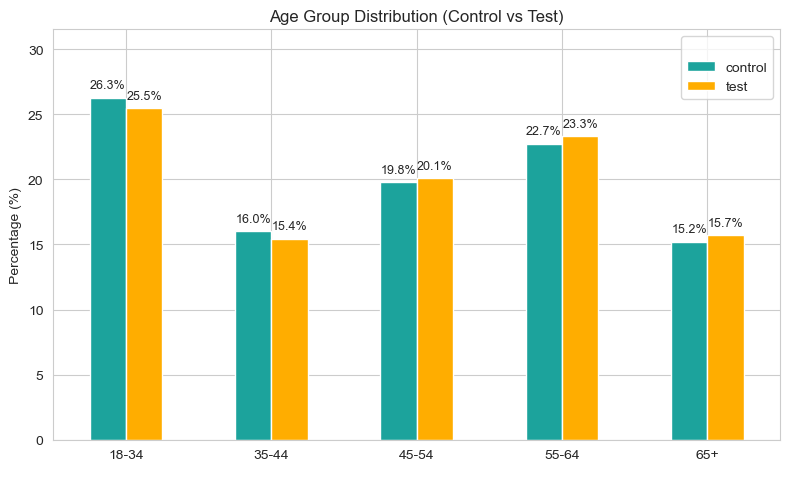

In [630]:
# Step 1: count values
age_pct = (
    clean_data
    .groupby(["variation", "age_group"])
    .size()
    .reset_index(name="count")
)

# Step 2: convert to percentage within each variation
age_pct["pct"] = age_pct.groupby("variation")["count"].transform(
    lambda x: x / x.sum() * 100
)

# Step 3: pivot for plotting
age_pivot = age_pct.pivot(
    index="age_group",
    columns="variation",
    values="pct"
).sort_index()

# Step 4: plot
ax = age_pivot.plot(
    kind="bar",
    figsize=(8,5),
    color=["#1ca39c", "#ffad00"]
)

# Step 5: labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.5,
                f"{height:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9
            )

plt.title("Age Group Distribution (Control vs Test)")
plt.xlabel(" ")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.ylim(0, age_pivot.max().max() * 1.2)
plt.legend(title=" ")
plt.tight_layout()
plt.show()

## Validate A/B test assignment

In [631]:
# Check the unique client_ids
variation_check = clean_data.groupby("client_id")["variation"].nunique()

display(variation_check.value_counts())

invalid_clients = variation_check[variation_check > 1].index

print("Invalid clients:", len(invalid_clients))

clean_data = clean_data[~clean_data["client_id"].isin(invalid_clients)]


variation
1    50487
Name: count, dtype: int64

Invalid clients: 0


In [632]:
# Check the unique visit_ids
variation_check = clean_data.groupby("visit_id")["variation"].nunique()

display(variation_check.value_counts())

invalid_visits = variation_check[variation_check > 1].index

print("Invalid visits:", len(invalid_visits))

clean_data = clean_data[~clean_data["visit_id"].isin(invalid_visits)]

variation
1    69063
2      120
Name: count, dtype: int64

Invalid visits: 120


## Create session-level dataset

In [633]:

session_data = (
    clean_data
    .groupby(["variation", "client_id", "visitor_id", "visit_id"], as_index=False)
    .agg(
        max_step=("step_num", "max"),
        first_timestamp=("date_time", "min"),
        last_timestamp=("date_time", "max"),
        number_of_steps=("process_step", "count")
    )
)

session_data["completed"] = session_data["max_step"] == 4

session_data["session_duration_seconds"] = (
    session_data["last_timestamp"] - session_data["first_timestamp"]
).dt.total_seconds()

session_data.head()


,variation,client_id,visitor_id,visit_id,max_step,first_timestamp,last_timestamp,number_of_steps,completed,session_duration_seconds
0,control,1028,42237450_62128060588,557292053_87239438319_391157,3,2017-04-08 18:51:28,2017-04-08 19:00:26,9,False,538.0
1,control,1104,194240915_18158000533,543158812_46395476577_767725,0,2017-06-12 07:49:18,2017-06-12 07:49:18,1,False,0.0
2,control,1104,194240915_18158000533,643221571_99977972121_69283,0,2017-06-20 22:31:33,2017-06-20 22:31:33,1,False,0.0
3,control,1186,446844663_31615102958,507052512_11309370126_442139,0,2017-04-08 15:59:16,2017-04-08 15:59:16,1,False,0.0
4,control,1186,446844663_31615102958,795373564_99931517312_810896,2,2017-04-08 18:05:02,2017-04-08 18:05:24,3,False,22.0


## Check the Time spent per step per Session and per Step

In [634]:
# 1. Sort properly
final_dataset = final_dataset.sort_values(
    ["client_id", "visitor_id", "visit_id", "date_time"]
).copy()

# 2. Compute time to next step
final_dataset["next_time"] = (
    final_dataset
    .groupby(["client_id", "visitor_id", "visit_id"])["date_time"]
    .shift(-1)
)

# 3. Duration between steps
final_dataset["step_duration_sec"] = (
    final_dataset["next_time"] - final_dataset["date_time"]
).dt.total_seconds()

# 4. Convert to minutes
final_dataset["step_duration_min"] = (
    final_dataset["step_duration_sec"] / 60
)

# 5. Optional check: same summary as before
avg_time_step = (
    final_dataset
    .dropna(subset=["step_duration_sec"])
    .groupby(["variation", "process_step"], as_index=False)
    .agg(
        step_duration_sec=("step_duration_sec", "mean"),
        step_duration_min=("step_duration_min", "mean")
    )
)

avg_time_step

,variation,process_step,step_duration_sec,step_duration_min
0,control,confirm,169.404824,2.823414
1,control,start,66.910758,1.115179
2,control,step_1,50.483109,0.841385
3,control,step_2,92.093888,1.534898
4,control,step_3,137.436827,2.290614
5,test,confirm,243.549410,4.059157
6,test,start,61.501594,1.025027
7,test,step_1,60.695212,1.011587
8,test,step_2,88.891294,1.481522
9,test,step_3,129.813239,2.163554


In [635]:
avg_time_pivot = avg_time_step.pivot(
    index="process_step",
    columns="variation",
    values="step_duration_min"
)

# Optional: enforce correct step order
step_order = ["start", "step_1", "step_2", "step_3", "confirm"]
avg_time_pivot = avg_time_pivot.reindex(step_order)

<Figure size 800x500 with 0 Axes>

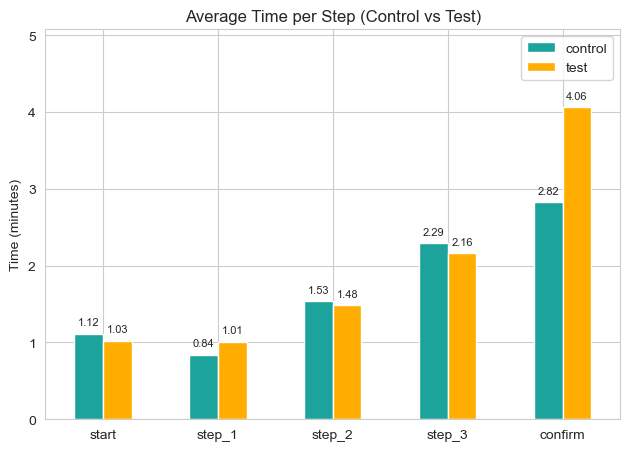

In [636]:
plt.figure(figsize=(8,5))

ax = avg_time_pivot.plot(
    kind="bar",
    color=["#1ca39c", "#ffad00"]
)

# Dynamic offset based on max value
offset = avg_time_pivot.max().max() * 0.02

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + offset,
                f"{height:.2f}",
                ha="center",
                va="bottom",
                fontsize=8  # slightly smaller
            )

plt.title("Average Time per Step (Control vs Test)")
plt.ylabel("Time (minutes)")
plt.xlabel(" ")
plt.xticks(rotation=0)

plt.ylim(0, avg_time_pivot.max().max() * 1.25)

plt.legend(title="")
plt.tight_layout()
plt.show()

In [637]:
# Steps in a funnel
steps = [0, 1, 2, 3, 4]  # start → confirm

funnel_counts = []

for var in session_data["variation"].unique():
    
    subset = session_data[session_data["variation"] == var]
    total_sessions = subset["visit_id"].nunique()
    
    for step in steps:
        
        reached = (subset["max_step"] >= step).sum()
        
        funnel_counts.append({
            "variation": var,
            "step_num": step,
            "sessions_reached": reached,
            "total_sessions": total_sessions,
            "percentage": reached / total_sessions * 100
        })

funnel_counts = pd.DataFrame(funnel_counts)

funnel_counts

,variation,step_num,sessions_reached,total_sessions,percentage
0,control,0,32115,32061,100.168429
1,control,1,24550,32061,76.572783
2,control,2,21063,32061,65.696641
3,control,3,19027,32061,59.346246
4,control,4,15979,32061,49.839369
5,test,0,37070,37002,100.183774
6,test,1,31990,37002,86.454786
7,test,2,28088,37002,75.909410
8,test,3,25523,37002,68.977353
9,test,4,21677,37002,58.583320


In [638]:
# Pivot table
funnel_pct = funnel_counts.pivot(
    index="step_num",
    columns="variation",
    values="percentage"
).sort_index()

funnel_pct

variation,control,test
step_num,,
0,100.168429,100.183774
1,76.572783,86.454786
2,65.696641,75.909410
3,59.346246,68.977353
4,49.839369,58.583320


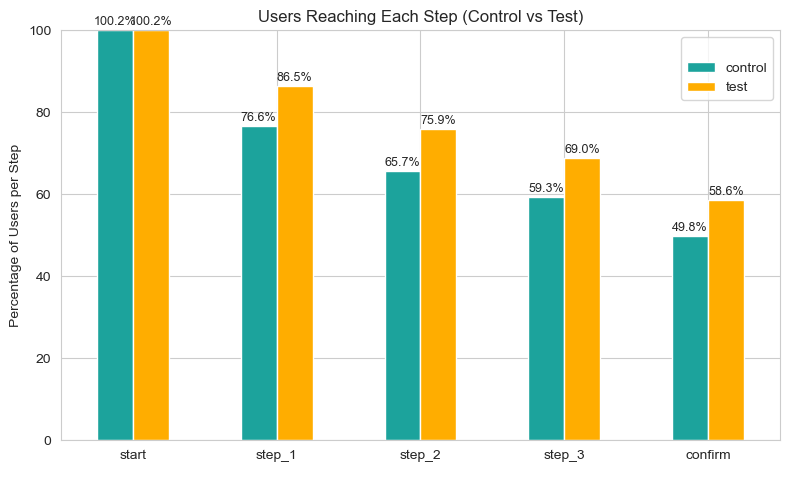

In [639]:
# Rename index before plotting
step_labels = {
    0: "start",
    1: "step_1",
    2: "step_2",
    3: "step_3",
    4: "confirm"
}

funnel_pct_named = funnel_pct.copy()
funnel_pct_named.index = funnel_pct_named.index.map(step_labels)

ax = funnel_pct_named.plot(
    kind="bar",
    figsize=(8,5),
    color=["#1ca39c", "#ffad00"]  # green = control, yellow = test
)

# Add labels on bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.5,
                f"{height:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9
            )

plt.title("Users Reaching Each Step (Control vs Test)")
plt.xlabel(" ")
plt.ylabel("Percentage of Users per Step")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title=" ")
plt.tight_layout()
plt.show()

## Merge session features back into clean data

## Create Error Features

This section creates error-related columns at event level.

An error is defined as either:

- a backward movement in the process
- or a skip forward of more than one step

Examples:

- `step_3 → step_2` = backward error
- `step_1 → step_3` = skip-forward error

In [640]:
# Sort data correctly within each visit/session
clean_data = clean_data.sort_values(
    by=["client_id", "visitor_id", "visit_id", "date_time"]
).copy()

# Previous step within the same visit
clean_data["previous_step_num"] = (
    clean_data
    .groupby(["client_id", "visitor_id", "visit_id"])["step_num"]
    .shift(1)
)

clean_data["previous_step"] = (
    clean_data
    .groupby(["client_id", "visitor_id", "visit_id"])["process_step"]
    .shift(1)
)

# Step difference
clean_data["step_diff"] = clean_data["step_num"] - clean_data["previous_step_num"]

# Error definition:
# 1. Backward movement
# 2. Skipping forward more than one step
clean_data["is_error"] = (
    (clean_data["step_diff"] < 0) |
    (clean_data["step_diff"] > 1)
)

# First step of each visit has no previous step, so it should not count as error
clean_data["is_error"] = clean_data["is_error"].fillna(False)

# Error type
clean_data["error_type"] = "valid"
clean_data.loc[clean_data["step_diff"] < 0, "error_type"] = "backward"
clean_data.loc[clean_data["step_diff"] > 1, "error_type"] = "skip_forward"
clean_data.loc[clean_data["previous_step_num"].isna(), "error_type"] = "first_step"

clean_data[
    ["client_id", "visit_id", "previous_step", "process_step", "step_diff", "is_error", "error_type"]
].head()

,client_id,visit_id,previous_step,process_step,step_diff,is_error,error_type
70411,555,637149525_38041617439_716659,NaN,start,NaN,False,first_step
70410,555,637149525_38041617439_716659,start,step_1,1.0,False,valid
70409,555,637149525_38041617439_716659,step_1,step_2,1.0,False,valid
70408,555,637149525_38041617439_716659,step_2,step_3,1.0,False,valid
70407,555,637149525_38041617439_716659,step_3,confirm,1.0,False,valid


In [641]:
error_by_variation = (
    clean_data
    .groupby("variation")
    .agg(
        total_actions=("process_step", "count"),
        total_errors=("is_error", "sum")
    )
    .reset_index()
)

error_by_variation["error_rate"] = (
    error_by_variation["total_errors"] / error_by_variation["total_actions"]
)

error_by_variation["error_rate_percent"] = (
    error_by_variation["error_rate"] * 100
).round(2)

error_by_variation

,variation,total_actions,total_errors,error_rate,error_rate_percent
0,control,139788,9913,0.070915,7.09
1,test,175898,16997,0.096630,9.66


In [642]:
error_by_step = (
    clean_data
    .groupby(["process_step", "variation"])
    .agg(
        total_actions=("process_step", "count"),
        total_errors=("is_error", "sum")
    )
    .reset_index()
)

error_by_step["error_rate"] = (
    error_by_step["total_errors"] / error_by_step["total_actions"]
)

error_by_step["error_rate_percent"] = (
    error_by_step["error_rate"] * 100
).round(2)

error_by_step

,process_step,variation,total_actions,total_errors,error_rate,error_rate_percent
0,confirm,control,17219,49,0.002846,0.28
1,confirm,test,25466,62,0.002435,0.24
2,start,control,45187,4788,0.105960,10.60
3,start,test,55562,10477,0.188564,18.86
4,step_1,control,29391,2294,0.078051,7.81
5,step_1,test,38492,3398,0.088278,8.83
6,step_2,control,25625,2471,0.096429,9.64
7,step_2,test,30748,2639,0.085827,8.58
8,step_3,control,22366,311,0.013905,1.39
9,step_3,test,25630,421,0.016426,1.64


In [643]:
error_by_age = (
    clean_data
    .groupby(["age_group", "variation"])
    .agg(
        total_actions=("process_step", "count"),
        total_errors=("is_error", "sum")
    )
    .reset_index()
)

error_by_age["error_rate"] = (
    error_by_age["total_errors"] / error_by_age["total_actions"]
)

error_by_age["error_rate_percent"] = (
    error_by_age["error_rate"] * 100
).round(2)

error_by_age

/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_22438/1957617406.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["age_group", "variation"])


,age_group,variation,total_actions,total_errors,error_rate,error_rate_percent
0,18-34,control,36657,2423,0.066099,6.61
1,18-34,test,44700,3310,0.074049,7.40
2,35-44,control,22320,1409,0.063127,6.31
3,35-44,test,27056,2113,0.078097,7.81
4,45-54,control,27585,1925,0.069784,6.98
5,45-54,test,35298,3522,0.099779,9.98
6,55-64,control,31779,2414,0.075962,7.60
7,55-64,test,40978,4676,0.114110,11.41
8,65+,control,21257,1734,0.081573,8.16
9,65+,test,27626,3361,0.121661,12.17


## Client-Level Calls and Logons Data

This section creates a client-level dataset for digital engagement analysis.

The variables used are:

- `calls_6_mnth`
- `logons_6_mnth`

Because these are client-level variables, we keep one row per client.

In [644]:
client_level_usage = clean_data[
    [
        "client_id",
        "variation",
        "age_group",
        "gendr",
        "calls_6_mnth",
        "logons_6_mnth",
        "num_accts",
        "bal",
        "clnt_tenure_yr",
        "clnt_tenure_mnth"
    ]
].drop_duplicates(subset=["client_id"])

# Optional cleaning: remove unknown gender if needed
client_level_usage = client_level_usage[
    client_level_usage["gendr"].notna()
]

client_level_usage.head()

,client_id,variation,age_group,gendr,calls_6_mnth,logons_6_mnth,num_accts,bal,clnt_tenure_yr,clnt_tenure_mnth
70411,555,test,18-34,U,2.0,6.0,2.0,25454.66,3.0,46.0
135189,647,test,55-64,M,0.0,4.0,2.0,30525.80,12.0,151.0
61217,934,test,45-54,F,0.0,3.0,2.0,32522.88,9.0,109.0
129532,1028,control,35-44,M,1.0,4.0,3.0,103520.22,12.0,145.0
249123,1104,control,45-54,U,6.0,9.0,3.0,154643.94,5.0,66.0


In [645]:
calls_logons_by_variation = (
    client_level_usage
    .groupby("variation")
    .agg(
        average_calls_6_mnth=("calls_6_mnth", "mean"),
        median_calls_6_mnth=("calls_6_mnth", "median"),
        average_logons_6_mnth=("logons_6_mnth", "mean"),
        median_logons_6_mnth=("logons_6_mnth", "median"),
        total_clients=("client_id", "nunique")
    )
    .reset_index()
    .round(2)
)

calls_logons_by_variation

,variation,average_calls_6_mnth,median_calls_6_mnth,average_logons_6_mnth,median_logons_6_mnth,total_clients
0,control,3.13,3.0,6.17,6.0,23435
1,test,3.06,3.0,6.10,6.0,26866


In [646]:
calls_logons_by_age = (
    client_level_usage
    .groupby(["age_group", "variation"])
    .agg(
        average_calls_6_mnth=("calls_6_mnth", "mean"),
        median_calls_6_mnth=("calls_6_mnth", "median"),
        average_logons_6_mnth=("logons_6_mnth", "mean"),
        median_logons_6_mnth=("logons_6_mnth", "median"),
        total_clients=("client_id", "nunique")
    )
    .reset_index()
    .round(2)
)

calls_logons_by_age

/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_22438/700467660.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["age_group", "variation"])


,age_group,variation,average_calls_6_mnth,median_calls_6_mnth,average_logons_6_mnth,median_logons_6_mnth,total_clients
0,18-34,control,3.19,3.0,6.21,6.0,6521
1,18-34,test,3.07,3.0,6.09,6.0,7699
2,35-44,control,2.85,2.0,5.87,6.0,3943
3,35-44,test,2.79,2.0,5.82,5.0,4539
4,45-54,control,2.94,3.0,5.97,6.0,4589
5,45-54,test,2.93,3.0,5.97,6.0,5337
6,55-64,control,3.22,3.0,6.26,6.0,5050
7,55-64,test,3.19,3.0,6.23,6.0,5598
8,65+,control,3.51,4.0,6.59,7.0,3304
9,65+,test,3.40,3.0,6.49,7.0,3659


In [647]:
calls_logons_by_age_gender = (
    client_level_usage
    .groupby(["age_group", "gendr", "variation"])
    .agg(
        average_calls_6_mnth=("calls_6_mnth", "mean"),
        average_logons_6_mnth=("logons_6_mnth", "mean"),
        total_clients=("client_id", "nunique")
    )
    .reset_index()
    .round(2)
)

calls_logons_by_age_gender

/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_22438/954432625.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["age_group", "gendr", "variation"])


,age_group,gendr,variation,average_calls_6_mnth,average_logons_6_mnth,total_clients
0,18-34,F,control,2.75,5.78,1442
1,18-34,F,test,2.57,5.60,1717
2,18-34,M,control,3.50,6.52,1713
3,18-34,M,test,3.39,6.40,2027
4,18-34,U,control,3.22,6.23,3366
5,18-34,U,test,3.12,6.14,3955
6,35-44,F,control,2.52,5.55,1262
7,35-44,F,test,2.51,5.53,1534
8,35-44,M,control,3.12,6.14,1445
9,35-44,M,test,3.16,6.18,1594


## Final checks

In [648]:

print("Final clean data shape:", clean_data.shape)
print("Final session data shape:", session_data.shape)

display(clean_data["variation"].value_counts())
display(clean_data["process_step"].value_counts())
display(clean_data.isna().sum())


Final clean data shape: (315686, 25)
Final session data shape: (69185, 10)


variation
test       175898
control    139788
Name: count, dtype: int64

process_step
start      100749
step_1      67883
step_2      56373
step_3      47996
confirm     42685
Name: count, dtype: int64

client_id                0
visitor_id               0
visit_id                 0
process_step             0
date_time                0
step_num                 0
date                     0
time                     0
hour                     0
weekday                  0
clnt_tenure_yr           0
clnt_tenure_mnth         0
clnt_age                 0
gendr                    0
num_accts                0
bal                      0
calls_6_mnth             0
logons_6_mnth            0
age_group              430
variation                0
previous_step_num    69185
previous_step        69185
step_diff            69185
is_error                 0
error_type               0
dtype: int64

## Export clean data

In [649]:
from pathlib import Path

PROCESSED_DATA_PATH = Path("processed_data")
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

final_dataset.to_csv(PROCESSED_DATA_PATH / "final_vanguard_dataset.csv", index=False)

print("✅ Saved final_vanguard_dataset.csv")

✅ Saved final_vanguard_dataset.csv


In [650]:
# ============================================================
# SESSION-LEVEL DATA + COMPLETION RATE
# ============================================================

session_data = (
    clean_data
    .groupby(["variation", "client_id", "visitor_id", "visit_id"], as_index=False)
    .agg(
        max_step=("step_num", "max"),
        first_timestamp=("date_time", "min"),
        last_timestamp=("date_time", "max"),
        number_of_steps=("process_step", "count")
    )
)

session_data["completed"] = session_data["max_step"] == 4

session_data["session_duration_seconds"] = (
    session_data["last_timestamp"] - session_data["first_timestamp"]
).dt.total_seconds()


# ============================================================
# COMPLETION RATE SUMMARY
# ============================================================

completion_summary = (
    session_data
    .groupby("variation", as_index=False)
    .agg(
        total_sessions=("visit_id", "count"),
        completed_sessions=("completed", "sum")
    )
)

completion_summary["completion_rate"] = (
    completion_summary["completed_sessions"] / completion_summary["total_sessions"]
)

completion_summary["completion_rate_percent"] = (
    completion_summary["completion_rate"] * 100
).round(2)

display(completion_summary)

,variation,total_sessions,completed_sessions,completion_rate,completion_rate_percent
0,control,32115,15979,0.497556,49.76
1,test,37070,21677,0.584759,58.48


In [651]:
from pathlib import Path

PROCESSED_DATA_PATH = Path("processed_data")
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

# Add session-level fields back to the clean step-level data
final_dataset = clean_data.merge(
    session_data[
        [
            "variation",
            "client_id",
            "visitor_id",
            "visit_id",
            "completed",
            "max_step",
            "session_duration_seconds",
            "number_of_steps"
        ]
    ],
    on=["variation", "client_id", "visitor_id", "visit_id"],
    how="left"
)


# Export ONE final CSV only
final_dataset.to_csv(
    PROCESSED_DATA_PATH / "final_vanguard_dataset.csv",
    index=False
)

print("✅ Saved one final file: processed_data/final_vanguard_dataset.csv")
print("Shape:", final_dataset.shape)
print("Columns:")
print(final_dataset.columns.tolist())

✅ Saved one final file: processed_data/final_vanguard_dataset.csv
Shape: (315686, 29)
Columns:
['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time', 'step_num', 'date', 'time', 'hour', 'weekday', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth', 'age_group', 'variation', 'previous_step_num', 'previous_step', 'step_diff', 'is_error', 'error_type', 'completed', 'max_step', 'session_duration_seconds', 'number_of_steps']


In [652]:
from pathlib import Path

PROCESSED_DATA_PATH = Path("processed_data")
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

final_dataset.to_csv(
    PROCESSED_DATA_PATH / "final_vanguard_dataset.csv",
    index=False
)

print("✅ Saved: processed_data/final_vanguard_dataset.csv")

✅ Saved: processed_data/final_vanguard_dataset.csv


In [653]:
cols_to_drop = [
    "date",
    "time",
    "weekday",
    "hour",
    "step_diff",
    "number_of_steps",
    "max_step",        
    "previous_step",
    "previous_step_num"
]

final_dataset = final_dataset.drop(
    columns=[col for col in cols_to_drop if col in final_dataset.columns],
    errors="ignore"
)

In [654]:
from pathlib import Path

PROCESSED_DATA_PATH = Path("processed_data")
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

# Make sure date_time is datetime
final_dataset["date_time"] = pd.to_datetime(final_dataset["date_time"])

# Sort properly
final_dataset = final_dataset.sort_values(
    ["client_id", "visitor_id", "visit_id", "date_time"]
).copy()

# Calculate next timestamp within each session
final_dataset["next_time"] = (
    final_dataset
    .groupby(["client_id", "visitor_id", "visit_id"])["date_time"]
    .shift(-1)
)

# Calculate step duration
final_dataset["step_duration_sec"] = (
    final_dataset["next_time"] - final_dataset["date_time"]
).dt.total_seconds()

final_dataset["step_duration_min"] = (
    final_dataset["step_duration_sec"] / 60
)

# Export and overwrite the CSV
output_path = PROCESSED_DATA_PATH / "final_vanguard_dataset.csv"

final_dataset.to_csv(output_path, index=False)

print("✅ CSV updated:", output_path.resolve())
print("Shape:", final_dataset.shape)
print("New columns added:")
print([col for col in final_dataset.columns if "step_duration" in col])

✅ CSV updated: /Users/ale/Desktop/Project 3/vanguard-ab-test/processed_data/final_vanguard_dataset.csv
Shape: (315686, 23)
New columns added:
['step_duration_sec', 'step_duration_min']
